<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
Supplementary code for the <a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a> book by <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>Code repository: <a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
<br>汉化的库: <a href="https://github.com/GoatCsu/CN-LLMs-from-scratch.git">https://github.com/GoatCsu/CN-LLMs-from-scratch.git</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>


## 附录 D：为训练循环添加额外的功能与优化

- 在本附录中，我们为训练函数添加了一些更高级的功能，这些功能通常用于预训练和微调；微调将在第6章和第7章中详细讨论。
- 以下三节将介绍学习率预热、余弦衰减和梯度裁剪。
- 最后一节将这些技术整合到训练函数中。

- 我们首先通过复用第5章的代码来初始化一个模型：

In [10]:
from importlib.metadata import version
import torch
# 输出当前 PyTorch 的版本
print("torch version:", version("torch"))

from previous_chapters import GPTModel

# 定义 GPT 模型的配置
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # 词汇表大小
    "context_length": 256, # 缩短的上下文长度 （原始长度:1024）
    "emb_dim": 768,        # 嵌入维度
    "n_heads": 12,         # 注意力头的数量
    "n_layers": 12,        # 层数
    "drop_rate": 0.1,      # Dropout 比率
    "qkv_bias": False      # 查询-键-值偏置
}
# 根据可用的设备选择运行环境
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 设置随机种子
torch.manual_seed(123)
# 初始化模型
model = GPTModel(GPT_CONFIG_124M)
model.eval()  # 禁用推理期间的 Dropout

torch version: 2.12.0


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

- 用跟第五章相同的代码

In [11]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode('utf-8')
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

In [12]:
from previous_chapters import create_dataloader_v1

# 训练集/验证集比率
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    text_data[:split_idx],
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    text_data[split_idx:],
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

# ------------ 打印查看 ------------
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")  # 初始化tokenizer（和create_dataloader_v1内部保持一致）

def print_dataloader_details(dataloader, name="DataLoader", num_batches=1):
    """
    打印 DataLoader 里的数据详情
    :param dataloader: train_loader 或 val_loader
    :param name: 数据集名称（用于打印区分）
    :param num_batches: 打印多少个batch，设为-1可打印全部
    """
    print(f"\n===== {name} 数据详情 =====")
    for batch_idx, (input_ids, target_ids) in enumerate(dataloader):
        print(f"\n--- Batch {batch_idx+1} ---")
        print(f"输入 shape: {input_ids.shape}")   # (batch_size, max_length)
        print(f"目标 shape: {target_ids.shape}")

        # 遍历当前batch里的每个样本
        for sample_idx in range(input_ids.size(0)):
            print(f"\n样本 {sample_idx+1}:")
            # 取出当前样本的token序列
            inp_tokens = input_ids[sample_idx].tolist()
            tgt_tokens = target_ids[sample_idx].tolist()

            # 还原成文本
            inp_text = tokenizer.decode(inp_tokens)
            tgt_text = tokenizer.decode(tgt_tokens)

            print(f"输入文本（前150字）:\n{inp_text[:150]}...")
            print(f"目标文本（前150字）:\n{tgt_text[:150]}...")
            print(f"输入前10个token: {inp_tokens[:10]}")
            print(f"目标前10个token: {tgt_tokens[:10]}")
            print("输入与目标是否满足右移一位关系:", inp_tokens[1:] == tgt_tokens[:-1])

        if num_batches != -1 and batch_idx + 1 >= num_batches:
            break

# 查看训练集前1个batch的数据详情
print_dataloader_details(train_loader, name="训练集", num_batches=1)
# 查看验证集前1个batch的数据详情
print_dataloader_details(val_loader, name="验证集", num_batches=1)


===== 训练集 数据详情 =====

--- Batch 1 ---
输入 shape: torch.Size([2, 256])
目标 shape: torch.Size([2, 256])

样本 1:
输入文本（前150字）:
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of...
目标文本（前150字）:
 HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of ...
输入前10个token: [40, 367, 2885, 1464, 1807, 3619, 402, 271, 10899, 2138]
目标前10个token: [367, 2885, 1464, 1807, 3619, 402, 271, 10899, 2138, 257]
输入与目标是否满足右移一位关系: True

样本 2:
输入文本（前150字）:
 oval canvases, in the inevitable garlanded frame. The mere outline of the frame called up all Gisburn's past!

Mrs. Gisburn drew back the window-curt...
目标文本（前150字）:
 canvases, in the inevitable garlanded frame. The mere outline of the frame called up all Gisburn's past!

Mrs. Gisburn drew back the window-curtains,...
输入前10个token: [41186, 39614, 1386, 11, 287, 262, 13203,

## D.1 学习率预热

- 引入学习率预热（Learning Rate Warmup）可以帮助稳定复杂模型（如大语言模型）的训练过程。
- 在学习率预热中，我们将学习率从一个非常低的初始值（`initial_lr`）逐渐增加到用户指定的最大值（`peak_lr`）。
- 通过这种方式，模型在训练开始时会以较小的权重更新启动，从而降低训练过程中因大幅更新导致不稳定的风险。

In [13]:
n_epochs = 15  # 训练总轮数
initial_lr = 0.0001  # 预热阶段的初始学习率（非常小，防止训练初期权重更新过猛）
peak_lr = 0.01       # 预热结束后要达到的目标学习率（也是正常训练阶段的学习率）

- 通常，预热步数占总步数的 0.1% 到 20%。
- 我们可以将学习率的增量计算为 `peak_lr` 和 `initial_lr` 之差，再除以预热步数。

In [14]:
total_steps = len(train_loader) * n_epochs  # 训练的总步数 = 每个 epoch 的 batch 数 × epoch 数
warmup_steps = int(0.2 * total_steps)       # 预热步数，这里设置为总步数的 20%，是行业常用比例（通常 0.1~20%）
print(warmup_steps)

27


- 请注意，印刷版书籍中意外包含了一行多余的代码 `warmup_steps = 20`，该代码未被使用，可以安全忽略。

In [15]:
lr_increment = (peak_lr - initial_lr) / warmup_steps  # 每一步的学习率增量（达成 warmup_steps 步时，从 initial_lr 线性增加到 peak_lr）
global_step = -1  # 全局训练步数，每处理一个 batch 就+1，用来判断当前处于预热阶段还是正常训练阶段
track_lrs = []    # 用来记录每一步的学习率，方便后续画图观察变化
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1
        # 算 lr
        if global_step < warmup_steps:  # 当步数还没到预热步数时，线性增加学习率
            lr = initial_lr + global_step * lr_increment
        else:                           # 步数超过预热步数后，学习率保持peak_lr不变
            lr = peak_lr
        # 将计算后的学习率立即更新到优化器上
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        track_lrs.append(optimizer.param_groups[0]["lr"])  # 方便后续可视化
    
        # 计算损失和更新权重（正常训练）
        # ...

'''
完整流程一句话总结
1.先算好预热阶段每一步要增加多少学习率
2.每处理一个 batch，更新全局步数，计算当前 lr
3.预热阶段：lr 从initial_lr线性涨到peak_lr
4.预热结束后：lr 固定为peak_lr（或接其他衰减策略）
5.把计算好的 lr 写入优化器，然后正常反向传播更新权重

补充说明：为什么要这么做？
大模型训练初期，权重是随机初始化的，此时如果用很大的学习率，很容易让模型在参数空间里 “乱跑”，导致训练不稳定、loss 直接爆炸
预热阶段用很小的 lr，让模型先 “慢慢熟悉” 数据，找到一个比较好的初始方向
等模型稳定后，再把 lr 升到正常水平，加快收敛
'''

'\n完整流程一句话总结\n1.先算好预热阶段每一步要增加多少学习率\n2.每处理一个 batch，更新全局步数，计算当前 lr\n3.预热阶段：lr 从initial_lr线性涨到peak_lr\n4.预热结束后：lr 固定为peak_lr（或接其他衰减策略）\n5.把计算好的 lr 写入优化器，然后正常反向传播更新权重\n\n补充说明：为什么要这么做？\n大模型训练初期，权重是随机初始化的，此时如果用很大的学习率，很容易让模型在参数空间里 “乱跑”，导致训练不稳定、loss 直接爆炸\n预热阶段用很小的 lr，让模型先 “慢慢熟悉” 数据，找到一个比较好的初始方向\n等模型稳定后，再把 lr 升到正常水平，加快收敛\n'

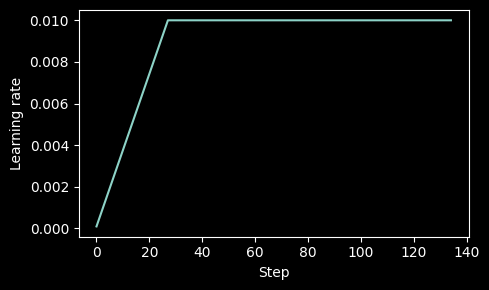

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.ylabel("Learning rate")
plt.xlabel("Step")
total_training_steps = len(train_loader) * n_epochs
plt.plot(range(total_training_steps), track_lrs)
plt.tight_layout(); plt.savefig("1.pdf")
plt.show()

## D.2 余弦衰减

- 另一种用于训练复杂深度神经网络的常见技术是余弦衰减，它同样在训练过程中调整学习率。
- 在余弦衰减中，学习率遵循一个余弦曲线，按照半余弦周期从初始值逐渐减少到接近零。
- 这种逐步减小的设计旨在随着模型权重的优化逐渐减缓学习速度，从而降低在训练后期超过最小值的风险，这对于稳定训练过程至关重要。
- 与线性衰减相比，余弦衰减因其学习率调整的平滑过渡而更受欢迎，但线性衰减在实践中也被广泛应用（例如，[OLMo: Accelerating the Science of Language Models](https://arxiv.org/abs/2402.00838)）。

In [17]:
import math

min_lr = 0.1 * initial_lr  # 余弦衰减阶段的最小学习率，这里设为 initial_lr 的 0.1 倍，防止学习率降到 0
track_lrs = []    # 记录每一步学习率，画图
lr_increment = (peak_lr - initial_lr) / warmup_steps  # 预热阶段每一步的学习率增量
global_step = -1  # 全局训练步数，每处理一个 batch+1，用来判断当前处于哪个阶段

for epoch in range(n_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1
        # 根据当前阶段（预热或余弦退火）调整学习率
        if global_step < warmup_steps:
            # 线性预热
            lr = initial_lr + global_step * lr_increment  
        else:
            # 在预热后进行余弦衰减
            progress = ((global_step - warmup_steps) / (total_training_steps - warmup_steps))
            lr = min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))
            '''
            这是标准的半周期余弦退火公式，我们拆解一下：
            1.  math.cos(math.pi * progress)：当 progress 从 0→1 时，cos值从 1→-1
            2.  1 + math.cos(...)：把结果映射到 [2, 0]
            3.  * 0.5：再映射回 [1, 0]
            4.  (peak_lr - min_lr) * ...：让学习率从 peak_lr 平滑降到 min_lr
            5.  + min_lr：最终学习率的范围是 [min_lr, peak_lr]
            '''
        # 将计算后的学习率应用到优化器上
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        track_lrs.append(optimizer.param_groups[0]["lr"])
    
        # 计算损失和更新权重...

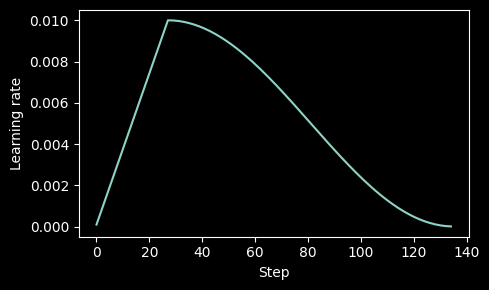

In [18]:
plt.figure(figsize=(5, 3))
plt.ylabel("Learning rate")
plt.xlabel("Step")
plt.plot(range(total_training_steps), track_lrs)
plt.tight_layout(); plt.savefig("2.pdf")
plt.show()
'''
完整流程一句话总结
预热阶段: 学习率从 initial_lr 线性涨到 peak_lr，让模型平稳起步
衰减阶段: 学习率按余弦曲线从 peak_lr 平滑降到 min_lr，后期用小 lr 精细调整

和 纯预热/纯线性衰减 的区别
纯预热:  lr 升到 peak 后就不变了，后期容易震荡
线性衰减: lr 从 peak 直线下降，拐点处不够平滑
余弦衰减: lr 下降是平滑的余弦曲线，没有硬拐点，后期也能缓慢下降，更稳定
'''

## D.3 梯度裁剪

- 梯度裁剪（Gradient Clipping）是另一种在训练 LLM 时用于稳定训练过程的技术。
- 通过设置一个阈值，超出该限制的梯度会被缩小到一个最大幅值，从而确保在反向传播过程中对模型参数的更新保持在可控范围内。
- 例如，在 PyTorch 的 `clip_grad_norm_` 方法中设置 `max_norm=1.0`，意味着梯度的范数会被裁剪，确保其最大范数不超过 1.0。
- 这里的“范数”指的是梯度向量在模型参数空间中的长度（或幅值）的度量。
- 更具体地说，这指的是 L2 范数，也称为欧几里得范数。
- 数学上，对于一个向量 $\mathbf{v}$，其分量为 $\mathbf{v} = [v_1, v_2, \ldots, v_n]$，L2 范数定义为：
$$
\| \mathbf{v} \|_2 = \sqrt{v_1^2 + v_2^2 + \ldots + v_n^2}
$$

- L2 范数对于矩阵的计算方式类似。
- 假设我们的梯度矩阵为：
$$
G = \begin{bmatrix}
1 & 2 \\
2 & 4
\end{bmatrix}
$$

- 我们希望将这些梯度裁剪到 `max_norm` 为 1。

- 首先，计算这些梯度的 L2 范数：
$$
\|G\|_2 = \sqrt{1^2 + 2^2 + 2^2 + 4^2} = \sqrt{25} = 5
$$

- 由于 $\|G\|_2 = 5$ 大于我们的 `max_norm`（1），需要缩放梯度，使它们的范数正好为 1。缩放因子计算为：
$$
\text{缩放因子} = \frac{max\_norm}{\|G\|_2} = \frac{1}{5}
$$

- 因此，缩放后的梯度矩阵 $G'$ 为：
$$
G' = \frac{1}{5} \times G = \begin{bmatrix}
\frac{1}{5} & \frac{2}{5} \\
\frac{2}{5} & \frac{4}{5}
\end{bmatrix}
$$

- 让我们实际操作一下。
- 首先，我们初始化一个新模型，并像在常规训练循环中一样，为一个训练批次计算损失。

In [19]:
from previous_chapters import calc_loss_batch

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)

loss = calc_loss_batch(input_batch, target_batch, model, device)
loss.backward()

- 调用 `.backward()` 后，PyTorch 会计算梯度，并将其存储在每个权重（参数）矩阵的 `.grad` 属性中。
- 让我们定义一个实用函数，用于基于所有模型权重计算最大梯度。

In [20]:
def find_highest_gradient(model):
    max_grad = None
    for param in model.parameters():
        if param.grad is not None:
            grad_values = param.grad.data.flatten()
            max_grad_param = grad_values.max()
            if max_grad is None or max_grad_param > max_grad:
                max_grad = max_grad_param
    return max_grad

print(find_highest_gradient(model))

tensor(0.0607)


- 在运用梯度裁切后,我们可以发现最大梯度明显的减小了

In [21]:
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
print(find_highest_gradient(model))

tensor(0.0266)


## D.4 D.4修改的训练函数

- 现在，让我们将上述三个概念（学习率预热、余弦衰减和梯度裁剪）添加到第5章中介绍的 `train_model_simple` 函数中，以创建下面更高级的 `train_model` 函数：

In [22]:
from previous_chapters import evaluate_model, generate_and_print_sample

BOOK_VERSION = True


def train_model(model, train_loader, val_loader, optimizer, device,
                n_epochs, eval_freq, eval_iter, start_context, tokenizer,
                warmup_steps, initial_lr=3e-05, min_lr=1e-6):

    train_losses, val_losses, track_tokens_seen, track_lrs = [], [], [], []
    tokens_seen, global_step = 0, -1

    # 从优化器中获取最大学习率
    peak_lr = optimizer.param_groups[0]["lr"]

    # 计算训练过程中总的迭代次数
    total_training_steps = len(train_loader) * n_epochs

    # 计算预热阶段学习率的增量
    lr_increment = (peak_lr - initial_lr) / warmup_steps

    for epoch in range(n_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            global_step += 1

            # 根据当前阶段（预热或余弦衰减）调整学习率
            if global_step < warmup_steps:
                # 线性预热
                lr = initial_lr + global_step * lr_increment  
            else:
                # 预热后余弦衰减
                progress = ((global_step - warmup_steps) / 
                            (total_training_steps - warmup_steps))
                lr = min_lr + (peak_lr - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

            # 将计算出的学习率应用到优化器中
            for param_group in optimizer.param_groups:
                param_group["lr"] = lr
            track_lrs.append(lr)  # 记录当前学习率

            # 计算并反向传播损失
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()

            # 在预热阶段后应用梯度裁剪，防止梯度爆炸
            if BOOK_VERSION:
                if global_step > warmup_steps:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  
            else:
                if global_step >= warmup_steps:  # 原书版本使用 global_step > warmup_steps，导致预热后跳过一次梯度裁剪
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                
            optimizer.step()
            tokens_seen += input_batch.numel()

            # 定期对训练集和验证集进行评估
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader,
                    device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                # 打印当前损失
                print(f"Ep {epoch+1} (Iter {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

        # 生成并打印模型的采样输出以监控训练进展
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen, track_lrs

In [23]:
import tiktoken

# 注意：
# 取消注释以下代码以计算执行时间
# import time
# start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)

peak_lr = 0.001  # 书中原始设置为 5e-4，这是一个错误
optimizer = torch.optim.AdamW(model.parameters(), lr=peak_lr, weight_decay=0.1)  # 书中错误地省略了 lr 的设置
tokenizer = tiktoken.get_encoding("gpt2")

n_epochs = 15
train_losses, val_losses, tokens_seen, lrs = train_model(
    model, train_loader, val_loader, optimizer, device, n_epochs=n_epochs,
    eval_freq=5, eval_iter=1, start_context="Every effort moves you",
    tokenizer=tokenizer, warmup_steps=warmup_steps, 
    initial_lr=1e-5, min_lr=1e-5
)

# 注意：
# 取消注释以下代码以显示执行时间
# end_time = time.time()
# execution_time_minutes = (end_time - start_time) / 60
# print(f"训练完成，用时 {execution_time_minutes:.2f} 分钟。")

Ep 1 (Iter 000000): Train loss 10.934, Val loss 10.939
Ep 1 (Iter 000005): Train loss 9.151, Val loss 9.461
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 2 (Iter 000010): Train loss 7.949, Val loss 8.184
Ep 2 (Iter 000015): Train loss 6.362, Val loss 6.876
Every effort moves you,,,,,,,,,,,,,,,,,,, the,,,,,,,,, the,,,,,,,,,,, the,,,,,,,,
Ep 3 (Iter 000020): Train loss 5.851, Val loss 6.607
Ep 3 (Iter 000025): Train loss 5.751, Val loss 6.634
Every effort moves you. "I"I and I had to the to the to the and the of the to the of the to Gisburn, and the of the the of the of the to the to the of the of the of the to the of
Ep 4 (Iter 000030): Train loss 5.224, Val loss 6.943
Ep 4 (Iter 000035): Train loss 4.304, Val loss 6.512
Every effort moves you know   "--and--and--I                 ", and, and, and, and I had been, and, and " it.   
Ep 5 (Iter 000040): Train loss 3.737, Val loss 6.383
Every effort moves you know the picture to have the picture--his--his, the

- 从上面的结果可以看出，模型一开始会生成无法理解的词串，而到训练后期，它能够生成语法上或多或少正确的句子。
- 如果检查模型在训练后期生成的一些段落，会发现其中部分内容与训练集中的内容高度相似——这表明模型只是简单地记住了训练数据。
- 请注意，这里的过拟合是由于训练集非常非常小，并且我们对其进行了过多次迭代。
  - 此处的 LLM 训练主要是出于教学目的；我们的主要目标是验证模型是否能够学习生成连贯的文本。
  - 为避免花费数周或数月时间在昂贵硬件上训练大量数据，我们直接加载了预训练权重。

- 画图看一下效果

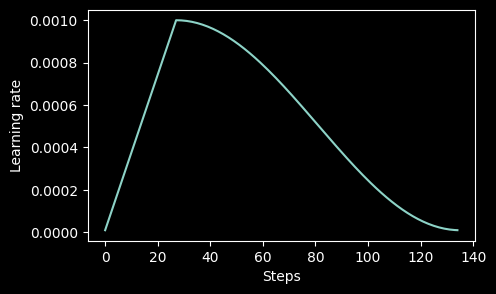

In [24]:
plt.figure(figsize=(5, 3))
plt.plot(range(len(lrs)), lrs)
plt.ylabel("Learning rate")
plt.xlabel("Steps")
plt.show()

- 看一下损失图

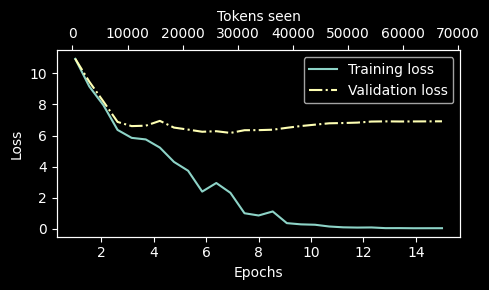

In [25]:
from previous_chapters import plot_losses

epochs_tensor = torch.linspace(1, n_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)
plt.tight_layout(); plt.savefig("3.pdf")
plt.show()

- 请注意，模型在此处出现过拟合是因为数据集被故意保持得非常小，这是为了教学目的（以便代码可以在笔记本电脑上运行）。
- 如果需要更长时间的预训练并使用更大的数据集，请参见 [../../ch05/03_bonus_pretraining_on_gutenberg](../../ch05/03_bonus_pretraining_on_gutenberg)。